# Exploración de la Base de Datos `saleshealth`
**Asignatura:** Gestión de Datos — UAX  
**Alumno:** Álvaro González Fernández  
**Fecha:** 2026-05-06

Este notebook realiza una exploración completa de la BD PostgreSQL `saleshealth`, que simula los sistemas ERP, CRM, logística y postventa de una empresa de productos de salud.

## 0. Imports y conexión

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sqlalchemy import create_engine, text

# Parámetros de conexión
DB_PARAMS = {
    'host': 'localhost',
    'port': 5432,
    'dbname': 'saleshealth',
    'user': 'postgres',
    'password': 'alvaro'
}

# Conexión psycopg2
conn = psycopg2.connect(**DB_PARAMS)
conn.autocommit = True
cur = conn.cursor()

# Engine SQLAlchemy (útil para pandas)
engine = create_engine(
    f"postgresql+psycopg2://{DB_PARAMS['user']}:{DB_PARAMS['password']}"
    f"@{DB_PARAMS['host']}:{DB_PARAMS['port']}/{DB_PARAMS['dbname']}"
)

print('✓ Conexión establecida con saleshealth')

✓ Conexión establecida con saleshealth


## 1. Listado de tablas con número de filas

Tablas encontradas: 17



,tabla,filas
0,sale_item,42555
1,sale,20000
2,customer,5750
3,return_item,2330
4,inventory,1000
5,product,50
6,central_product,49
7,central_inventory,49
8,city_zone,42
9,warehouse_location,40


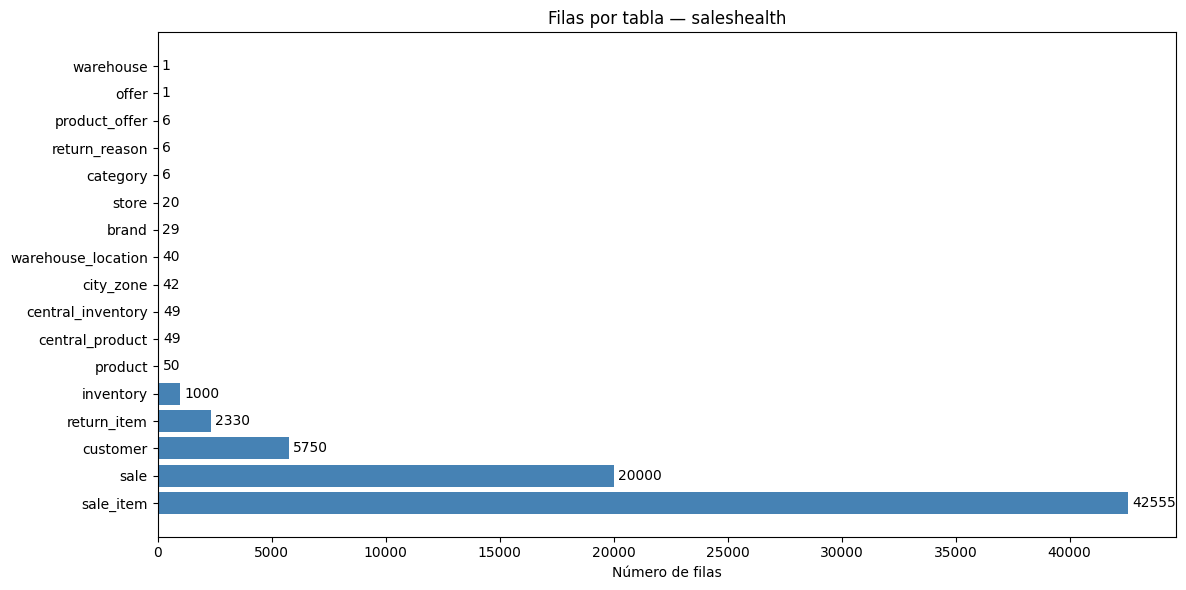

Gráfico guardado como tabla_filas.png


In [2]:
# Obtener todas las tablas del esquema público
tables_query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
  AND table_type = 'BASE TABLE'
ORDER BY table_name;
"""
cur.execute(tables_query)
tables = [row[0] for row in cur.fetchall()]

print(f'Tablas encontradas: {len(tables)}\n')

# Contar filas de cada tabla
row_counts = []
for t in tables:
    cur.execute(f'SELECT COUNT(*) FROM "{t}";')
    count = cur.fetchone()[0]
    row_counts.append({'tabla': t, 'filas': count})

df_tables = pd.DataFrame(row_counts).sort_values('filas', ascending=False).reset_index(drop=True)
display(df_tables)

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_tables['tabla'], df_tables['filas'], color='steelblue')
ax.set_xlabel('Número de filas')
ax.set_title('Filas por tabla — saleshealth')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig('tabla_filas.png', dpi=150)
plt.show()
print('Gráfico guardado como tabla_filas.png')

## 2. Estructura de cada tabla (columnas y tipos)

In [3]:
schema_query = """
SELECT
    c.table_name,
    c.column_name,
    c.data_type,
    c.character_maximum_length,
    c.numeric_precision,
    c.is_nullable,
    c.column_default,
    CASE WHEN pk.column_name IS NOT NULL THEN 'PK' ELSE '' END AS pk_flag
FROM information_schema.columns c
LEFT JOIN (
    SELECT ku.table_name, ku.column_name
    FROM information_schema.table_constraints tc
    JOIN information_schema.key_column_usage ku
        ON tc.constraint_name = ku.constraint_name
       AND tc.table_schema   = ku.table_schema
    WHERE tc.constraint_type = 'PRIMARY KEY'
      AND tc.table_schema    = 'public'
) pk ON pk.table_name = c.table_name AND pk.column_name = c.column_name
WHERE c.table_schema = 'public'
ORDER BY c.table_name, c.ordinal_position;
"""

df_schema = pd.read_sql(schema_query, engine)

sep = '=' * 60
for table in sorted(df_schema['table_name'].unique()):
    print(f'\n{sep}')
    print(f'  TABLA: {table.upper()}')
    print(sep)
    subset = df_schema[df_schema['table_name'] == table].copy()
    subset = subset[['column_name', 'data_type', 'character_maximum_length',
                      'numeric_precision', 'is_nullable', 'pk_flag']]
    subset.columns = ['Columna', 'Tipo', 'Max_Long', 'Precisión', 'Nullable', 'PK']
    display(subset.reset_index(drop=True))


  TABLA: BRAND


,Columna,Tipo,Max_Long,Precisión,Nullable,PK
0,brand_id,integer,NaN,32.0,NO,PK
1,name,character varying,150.0,NaN,NO,
2,country,character varying,100.0,NaN,YES,
3,website,character varying,200.0,NaN,YES,



  TABLA: CATEGORY


,Columna,Tipo,Max_Long,Precisión,Nullable,PK
0,category_id,integer,NaN,32.0,NO,PK
1,name,character varying,100.0,NaN,NO,
2,description,text,NaN,NaN,YES,



  TABLA: CENTRAL_INVENTORY


...

,Columna,Tipo,Max_Long,Precisión,Nullable,PK
0,store_id,integer,NaN,32.0,NO,PK
1,name,character varying,100.0,NaN,NO,
2,address,character varying,200.0,NaN,YES,
3,city,character varying,100.0,NaN,YES,
4,postal_code,character varying,10.0,NaN,YES,
5,latitude,numeric,NaN,9.0,YES,
6,longitude,numeric,NaN,9.0,YES,
7,opened_date,date,NaN,NaN,YES,



  TABLA: WAREHOUSE


,Columna,Tipo,Max_Long,Precisión,Nullable,PK
0,warehouse_id,integer,NaN,32.0,NO,PK
1,name,character varying,150.0,NaN,NO,
2,address,character varying,200.0,NaN,YES,
3,city,character varying,100.0,NaN,YES,
4,postal_code,character varying,10.0,NaN,YES,
5,latitude,numeric,NaN,9.0,YES,
6,longitude,numeric,NaN,9.0,YES,



  TABLA: WAREHOUSE_LOCATION


,Columna,Tipo,Max_Long,Precisión,Nullable,PK
0,location_id,integer,NaN,32.0,NO,PK
1,warehouse_id,integer,NaN,32.0,YES,
2,zone,character varying,50.0,NaN,YES,
3,aisle,character varying,10.0,NaN,YES,
4,shelf,character varying,10.0,NaN,YES,
5,bin_code,character varying,10.0,NaN,YES,


## 3. Relaciones entre tablas (Foreign Keys)

In [4]:
fk_query = """
SELECT
    tc.table_name          AS tabla_origen,
    kcu.column_name        AS columna_fk,
    ccu.table_name         AS tabla_destino,
    ccu.column_name        AS columna_referenciada,
    tc.constraint_name
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
    ON tc.constraint_name = kcu.constraint_name
   AND tc.table_schema    = kcu.table_schema
JOIN information_schema.constraint_column_usage ccu
    ON ccu.constraint_name = tc.constraint_name
   AND ccu.table_schema    = tc.table_schema
WHERE tc.constraint_type = 'FOREIGN KEY'
  AND tc.table_schema    = 'public'
ORDER BY tc.table_name, kcu.column_name;
"""

df_fk = pd.read_sql(fk_query, engine)

print(f'Total de Foreign Keys encontradas: {len(df_fk)}\n')
display(df_fk[['tabla_origen', 'columna_fk', 'tabla_destino', 'columna_referenciada']])

Total de Foreign Keys encontradas: 16



,tabla_origen,columna_fk,tabla_destino,columna_referenciada
0,central_inventory,location_id,warehouse_location,location_id
1,central_inventory,product_id,central_product,product_id
2,central_inventory,warehouse_id,warehouse,warehouse_id
3,central_product,brand_id,brand,brand_id
4,central_product,category_id,category,category_id
5,inventory,product_id,product,product_id
6,inventory,store_id,store,store_id
7,product_offer,offer_id,offer,offer_id
8,product_offer,product_id,product,product_id
9,return_item,sale_item_id,sale_item,sale_item_id


## 4. Diagrama ER (grafo de relaciones entre tablas)

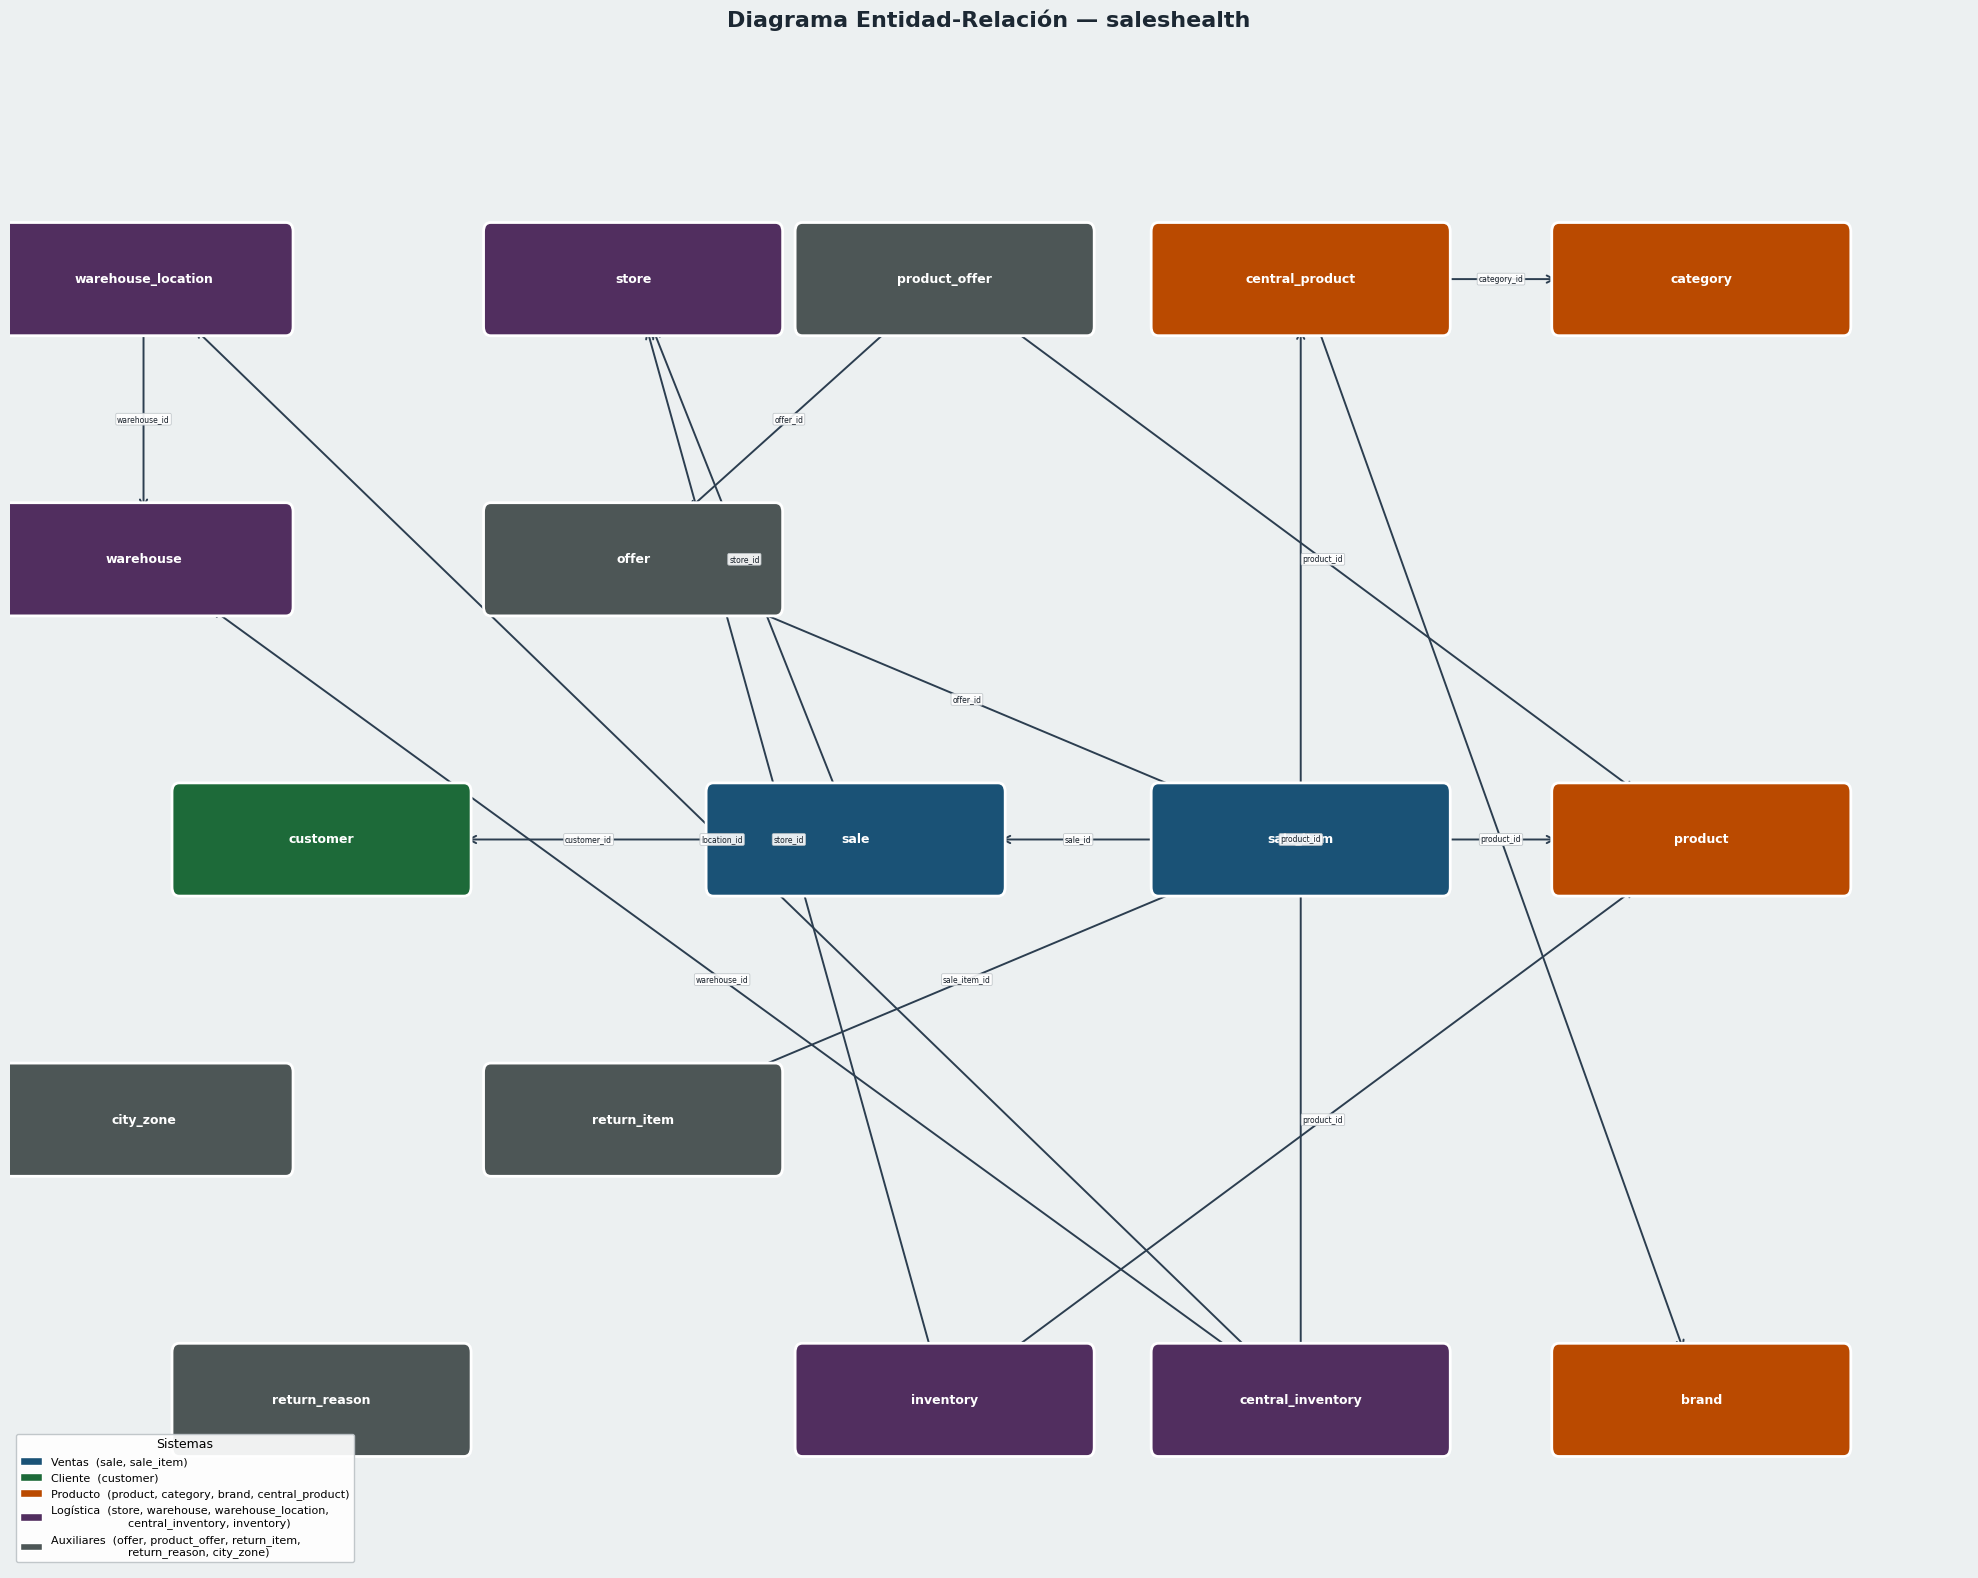

✓ Diagrama ER guardado como diagrama_er.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from collections import defaultdict

# ── Paleta de colores por sistema ───────────────────────────────────────────
COLORS = {
    'ventas':    '#1a5276',
    'cliente':   '#1d6a39',
    'producto':  '#ba4a00',
    'logistica': '#512e5f',
    'auxiliar':  '#4d5656',
}

TABLE_SYSTEM = {
    'sale':               'ventas',
    'sale_item':          'ventas',
    'customer':           'cliente',
    'product':            'producto',
    'category':           'producto',
    'brand':              'producto',
    'central_product':    'producto',
    'store':              'logistica',
    'warehouse':          'logistica',
    'warehouse_location': 'logistica',
    'central_inventory':  'logistica',
    'inventory':          'logistica',
    'offer':              'auxiliar',
    'product_offer':      'auxiliar',
    'return_item':        'auxiliar',
    'return_reason':      'auxiliar',
    'city_zone':          'auxiliar',
}

# ── Posiciones fijas (x, y) — centro de cada nodo ──────────────────────────
POS = {
    # Fila superior
    'warehouse_location': ( 1.0, 13.5),
    'store':              ( 6.5, 13.5),
    'product_offer':      (10.0, 13.5),
    'central_product':    (14.0, 13.5),
    'category':           (18.5, 13.5),
    # Fila media-alta
    'warehouse':          ( 1.0, 11.0),
    'offer':              ( 6.5, 11.0),
    # Fila central
    'customer':           ( 3.0,  8.5),
    'sale':               ( 9.0,  8.5),
    'sale_item':          (14.0,  8.5),
    'product':            (18.5,  8.5),
    # Fila media-baja
    'city_zone':          ( 1.0,  6.0),
    'return_item':        ( 6.5,  6.0),
    # Fila inferior
    'return_reason':      ( 3.0,  3.5),
    'inventory':          (10.0,  3.5),
    'central_inventory':  (14.0,  3.5),
    'brand':              (18.5,  3.5),
}

NODE_W, NODE_H = 3.2, 0.85

def box_edge(cx, cy, w, h, tx, ty):
    """Punto en el borde del rectángulo (cx,cy,w,h) en dirección a (tx,ty)."""
    dx, dy = tx - cx, ty - cy
    if abs(dx) < 1e-9 and abs(dy) < 1e-9:
        return cx, cy
    hw, hh = w / 2, h / 2
    if abs(dx) < 1e-9:
        s = hh / abs(dy)
    elif abs(dy) < 1e-9:
        s = hw / abs(dx)
    else:
        s = min(hw / abs(dx), hh / abs(dy))
    return cx + dx * s, cy + dy * s

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
ax.set_xlim(-0.5, 21.5)
ax.set_ylim(2.0, 15.5)
ax.set_facecolor('#ecf0f1')
fig.patch.set_facecolor('#ecf0f1')
ax.axis('off')
ax.set_title('Diagrama Entidad-Relación — saleshealth',
             fontsize=16, fontweight='bold', pad=20, color='#1c2833')

# ── Aristas (se dibujan primero, quedan debajo de los nodos) ────────────────
# Agrupamos FKs por par (origen, destino) para gestionar aristas paralelas
edge_groups = defaultdict(list)
for _, row in df_fk.iterrows():
    src, dst, lbl = row['tabla_origen'], row['tabla_destino'], row['columna_fk']
    if src in POS and dst in POS:
        edge_groups[(src, dst)].append(lbl)

for (src, dst), labels in edge_groups.items():
    sx, sy   = POS[src]
    dx_n, dy_n = POS[dst]
    n = len(labels)
    for i, lbl in enumerate(labels):
        # Aristas únicas: sin curvatura; paralelas: curvatura alternada
        rad = 0.0 if n == 1 else 0.12 * (i - (n - 1) / 2)
        ex0, ey0 = box_edge(sx,   sy,   NODE_W, NODE_H, dx_n, dy_n)
        ex1, ey1 = box_edge(dx_n, dy_n, NODE_W, NODE_H, sx,   sy)
        ax.annotate('',
            xy=(ex1, ey1), xytext=(ex0, ey0),
            arrowprops=dict(
                arrowstyle='->', color='#2c3e50', lw=1.4,
                mutation_scale=13,
                connectionstyle=f'arc3,rad={rad}',
            ), zorder=2
        )
        # Midpoint exacto de la curva de Bézier cuadrática (arc3)
        # P(0.5) = midpt + 0.5·rad·(ddy, −ddx)
        ddx, ddy = ex1 - ex0, ey1 - ey0
        mid_x = (ex0 + ex1) / 2 + 0.5 * rad * ddy
        mid_y = (ey0 + ey1) / 2 - 0.5 * rad * ddx
        ax.text(mid_x, mid_y, lbl,
                fontsize=5.5, ha='center', va='center', color='#17202a',
                bbox=dict(boxstyle='round,pad=0.18', fc='white',
                          alpha=0.90, ec='#bdc3c7', lw=0.6),
                zorder=5)

# ── Nodos (rectángulos coloreados con nombre completo) ──────────────────────
for table, (x, y) in POS.items():
    fc = COLORS[TABLE_SYSTEM.get(table, 'auxiliar')]
    ax.add_patch(FancyBboxPatch(
        (x - NODE_W / 2, y - NODE_H / 2), NODE_W, NODE_H,
        boxstyle='round,pad=0.08',
        facecolor=fc, edgecolor='white', linewidth=2.0, zorder=3
    ))
    ax.text(x, y, table,
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=4)

# ── Leyenda ──────────────────────────────────────────────────────────────────
ax.legend(
    handles=[
        mpatches.Patch(facecolor=COLORS['ventas'],    ec='white',
                       label='Ventas  (sale, sale_item)'),
        mpatches.Patch(facecolor=COLORS['cliente'],   ec='white',
                       label='Cliente  (customer)'),
        mpatches.Patch(facecolor=COLORS['producto'],  ec='white',
                       label='Producto  (product, category, brand, central_product)'),
        mpatches.Patch(facecolor=COLORS['logistica'], ec='white',
                       label='Logística  (store, warehouse, warehouse_location,\n'
                             '                      central_inventory, inventory)'),
        mpatches.Patch(facecolor=COLORS['auxiliar'],  ec='white',
                       label='Auxiliares  (offer, product_offer, return_item,\n'
                             '                      return_reason, city_zone)'),
    ],
    loc='lower left', fontsize=8, framealpha=0.92,
    edgecolor='#bdc3c7', title='Sistemas', title_fontsize=9,
    bbox_to_anchor=(0.0, 0.0)
)

plt.tight_layout(pad=1.5)
plt.savefig('diagrama_er.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✓ Diagrama ER guardado como diagrama_er.png')

## 5. Estadísticas descriptivas de columnas numéricas

In [6]:
# Para cada tabla, extraer estadísticas de columnas numéricas
numeric_types = ('integer', 'bigint', 'smallint', 'numeric', 'real',
                 'double precision', 'decimal', 'money')

numeric_cols = df_schema[
    df_schema['data_type'].isin(numeric_types)
][['table_name', 'column_name']]

stats_list = []
for _, row in numeric_cols.iterrows():
    t, c = row['table_name'], row['column_name']
    try:
        cur.execute(f"""
            SELECT
                '{t}' AS tabla,
                '{c}' AS columna,
                COUNT("{c}")                   AS count,
                ROUND(AVG("{c}")::numeric, 2)  AS media,
                ROUND(STDDEV("{c}")::numeric, 2) AS desv_std,
                MIN("{c}")                     AS min,
                MAX("{c}")                     AS max
            FROM "{t}";
        """)
        stats_list.append(cur.fetchone())
    except Exception as e:
        print(f'  [WARN] {t}.{c}: {e}')
        conn.rollback()

df_stats = pd.DataFrame(stats_list,
    columns=['tabla', 'columna', 'count', 'media', 'desv_std', 'min', 'max'])
print(f'Estadísticas de {len(df_stats)} columnas numéricas:')
display(df_stats)

Estadísticas de 49 columnas numéricas:


,tabla,columna,count,media,desv_std,min,max
0,brand,brand_id,29,15.00,8.51,1,29
1,category,category_id,6,3.50,1.87,1,6
2,central_inventory,inventory_id,49,25.00,14.29,1,49
3,central_inventory,warehouse_id,49,1.00,0.00,1,1
4,central_inventory,location_id,49,19.82,11.20,1,40
5,central_inventory,product_id,49,25.43,14.72,1,50
6,central_inventory,quantity,49,53.82,27.95,1,100
7,central_inventory,min_stock,49,5.00,0.00,5,5
8,central_inventory,max_stock,49,200.00,0.00,200,200
9,central_product,product_id,49,25.43,14.72,1,50


## 6. Detección de valores nulos por columna

In [7]:
null_list = []
for t in tables:
    cur.execute(f"""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = '{t}'
        ORDER BY ordinal_position;
    """)
    cols = [r[0] for r in cur.fetchall()]
    for c in cols:
        try:
            cur.execute(f'SELECT COUNT(*) FROM "{t}" WHERE "{c}" IS NULL;')
            nulls = cur.fetchone()[0]
            if nulls > 0:
                null_list.append({'tabla': t, 'columna': c, 'nulos': nulls})
        except Exception as e:
            conn.rollback()

df_nulls = pd.DataFrame(null_list).sort_values('nulos', ascending=False).reset_index(drop=True)
if df_nulls.empty:
    print('No se encontraron valores nulos en ninguna columna.')
else:
    print(f'Columnas con valores nulos ({len(df_nulls)}):')
    display(df_nulls)

Columnas con valores nulos (3):


,tabla,columna,nulos
0,sale_item,offer_id,42547
1,brand,website,8
2,city_zone,zone_orientation,1


## 7. Resumen final

In [8]:
total_rows = df_tables['filas'].sum()
total_cols = len(df_schema)
total_fk   = len(df_fk)

print('=' * 50)
print('  RESUMEN — BASE DE DATOS saleshealth')
print('=' * 50)
print(f'  Tablas       : {len(tables)}')
print(f'  Columnas     : {total_cols}')
print(f'  Filas totales: {total_rows:,}')
print(f'  Foreign Keys : {total_fk}')
print(f'  Nulos detect.: {len(df_nulls) if not df_nulls.empty else 0} columnas afectadas')
print('=' * 50)

# Cerrar conexiones
cur.close()
conn.close()
engine.dispose()
print('\n✓ Conexiones cerradas correctamente.')

  RESUMEN — BASE DE DATOS saleshealth
  Tablas       : 17
  Columnas     : 96
  Filas totales: 71,934
  Foreign Keys : 16
  Nulos detect.: 3 columnas afectadas

✓ Conexiones cerradas correctamente.
